In [2]:
# 1. Magic commands to auto-reload your .py file if you change it
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# 2. Add the 'src' folder to Python's path
# This assumes your notebook is in a 'notebooks' folder. 
# If your notebook is in the root folder, change '..' to '.'
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

# 3. Import your function
from data_loader import load_data

# 4. Define the path (Updated to match your actual CMaps folder)
# We go up one level (..), then into CMaps
data_path = '../CMaps/train_FD001.txt' 

# 5. Load the data
if os.path.exists(data_path):
    df_train = load_data(data_path)
    print("✅ Data Loaded Successfully!")
    print("Shape:", df_train.shape)
else:
    print(f"❌ Error: Could not find file at {data_path}")
    print("Please check if your notebook is inside a 'notebooks' folder.")

✅ Data Loaded Successfully!
Shape: (20631, 27)


In [9]:
df_train.head(193)

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,1,189,-0.0006,0.0002,100.0,518.67,644.18,1596.17,1428.01,14.62,...,2388.33,8117.51,8.5183,0.03,395,2388,100.0,38.48,23.1127,3
189,1,190,-0.0027,0.0001,100.0,518.67,643.64,1599.22,1425.95,14.62,...,2388.35,8112.58,8.5223,0.03,398,2388,100.0,38.49,23.0675,2
190,1,191,-0.0000,-0.0004,100.0,518.67,643.34,1602.36,1425.77,14.62,...,2388.30,8114.61,8.5174,0.03,394,2388,100.0,38.45,23.1295,1
191,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,2388.32,8110.93,8.5113,0.03,396,2388,100.0,38.48,22.9649,0


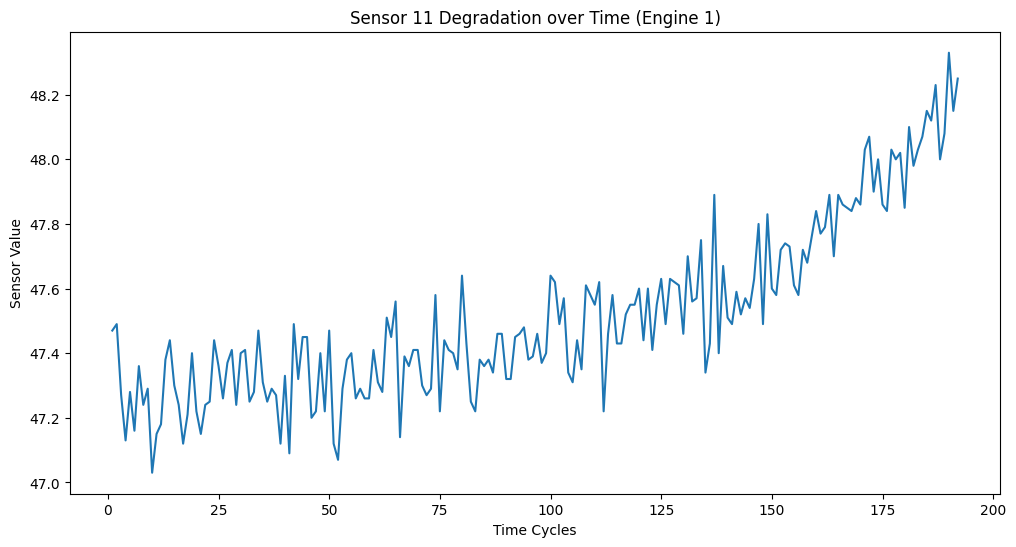

In [3]:
# Visualize Sensor 11 (High Pressure Turbine Cleanliness) vs RUL
plt.figure(figsize=(12, 6))
# We pick one engine (Unit 1) to see the trend clearly
one_engine = df_train[df_train['unit_nr'] == 1]
plt.plot(one_engine['time_cycles'], one_engine['s_11'])
plt.title('Sensor 11 Degradation over Time (Engine 1)')
plt.xlabel('Time Cycles')
plt.ylabel('Sensor Value')
plt.show()

In [4]:
# Select the sensor columns (s_1 to s_21)
sensor_cols = ['s_{}'.format(i) for i in range(1, 22)]

def engineer_features(df):
    # We use a window size of 5 cycles
    window_size = 5
    
    # Prepare lists to hold data
    df_rolling_mean = []
    df_rolling_std = []
    
    # CRITICAL: Group by 'unit_nr' so we don't mix data between engines!
    for unit in df['unit_nr'].unique():
        df_unit = df[df['unit_nr'] == unit]
        
        # Calculate Rolling Mean & Std
        # min_periods=1 ensures we don't lose the first 5 rows
        rolling_mean = df_unit[sensor_cols].rolling(window=window_size, min_periods=1).mean()
        rolling_std = df_unit[sensor_cols].rolling(window=window_size, min_periods=1).std().fillna(0)
        
        df_rolling_mean.append(rolling_mean)
        df_rolling_std.append(rolling_std)
    
    # Combine everything back together
    df_mean_final = pd.concat(df_rolling_mean)
    df_std_final = pd.concat(df_rolling_std)
    
    # Rename columns so we can distinguish them
    df_mean_final.columns = [col + '_rolling_mean' for col in sensor_cols]
    df_std_final.columns = [col + '_rolling_std' for col in sensor_cols]
    
    # Align indices
    df_mean_final.index = df.index
    df_std_final.index = df.index
    
    # Merge with original data
    df_out = pd.concat([df, df_mean_final, df_std_final], axis=1)
    
    return df_out

# Run the function on your data
df_train_engineered = engineer_features(df_train)

print("✅ Features Engineered!")
print(f"Original Column Count: {df_train.shape[1]}")
print(f"New Column Count: {df_train_engineered.shape[1]}")

✅ Features Engineered!
Original Column Count: 27
New Column Count: 69


In [ ]:
df_train_engineered.head() 

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12_rolling_std,s_13_rolling_std,s_14_rolling_std,s_15_rolling_std,s_16_rolling_std,s_17_rolling_std,s_18_rolling_std,s_19_rolling_std,s_20_rolling_std,s_21_rolling_std
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.438406,0.035355,5.041671,0.008697,0.0,0.000000,0.0,0.0,0.042426,0.003253
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.404475,0.026458,3.717450,0.007640,0.0,1.154701,0.0,0.0,0.055076,0.044573
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.495950,0.029439,3.050906,0.028117,0.0,1.000000,0.0,0.0,0.076322,0.037977
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.432574,0.025884,2.651326,0.025953,0.0,1.095445,0.0,0.0,0.073621,0.033498


In [18]:
df_train_engineered.nunique()

unit_nr               100
time_cycles           362
setting_1             158
setting_2              13
setting_3               1
                    ...  
s_17_rolling_std     1447
s_18_rolling_std        1
s_19_rolling_std        1
s_20_rolling_std    19889
s_21_rolling_std    20519
Length: 69, dtype: int64

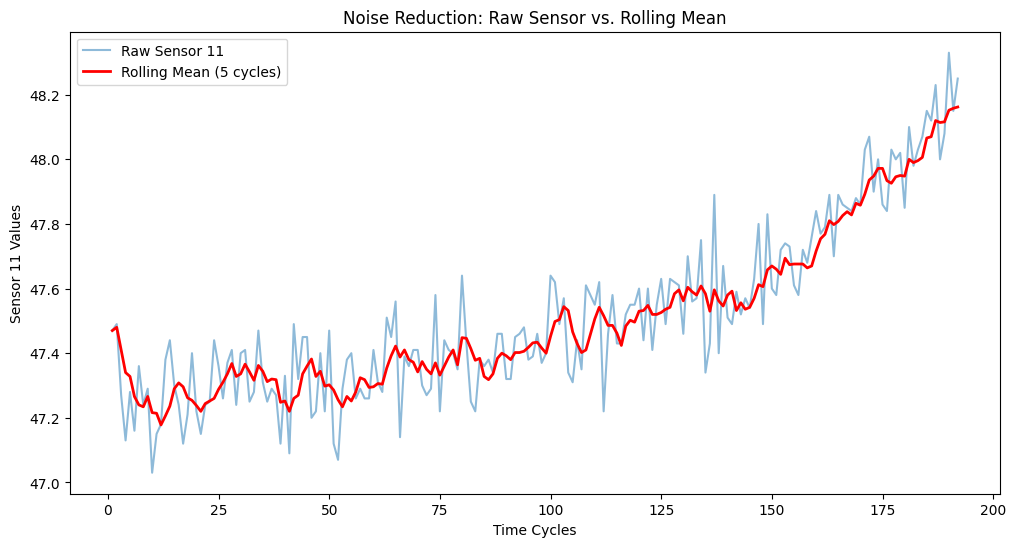

In [20]:
plt.figure(figsize=(12, 6))

# Filter for Engine 1 again
engine_1 = df_train_engineered[df_train_engineered['unit_nr'] == 1]

# Plot Raw Sensor Data (Light Blue, Noisy)
plt.plot(engine_1['time_cycles'], engine_1['s_11'], label='Raw Sensor 11', alpha=0.5)

# Plot Rolling Mean (Red, Smooth)
plt.plot(engine_1['time_cycles'], engine_1['s_11_rolling_mean'], label='Rolling Mean (5 cycles)', color='red', linewidth=2)

plt.title('Noise Reduction: Raw Sensor vs. Rolling Mean')
plt.xlabel('Time Cycles')
plt.ylabel('Sensor 11 Values')
plt.legend()
plt.show()

In [6]:
# We only want to check correlation with RUL
# Let's verify which features correlate most with RUL
corr_matrix = df_train_engineered.corr()

# Get the correlation of everything with 'RUL', sorted from highest to lowest
rul_correlation = corr_matrix['RUL'].sort_values(ascending=False)

print("Top 5 Positively Correlated Features:")
print(rul_correlation.head(5))

print("\nTop 5 Negatively Correlated Features:")
print(rul_correlation.tail(5))

# Check for "Flat line" sensors (Correlation is NaN because they never change)
print("\nUseless Sensors (No Correlation / Constant):")
print(rul_correlation[rul_correlation.isna()])

Top 5 Positively Correlated Features:
RUL                  1.000000
s_21_rolling_mean    0.724072
s_20_rolling_mean    0.717327
s_12_rolling_mean    0.713225
s_7_rolling_mean     0.712092
Name: RUL, dtype: float64

Top 5 Negatively Correlated Features:
s_5_rolling_std    NaN
s_10_rolling_std   NaN
s_16_rolling_std   NaN
s_18_rolling_std   NaN
s_19_rolling_std   NaN
Name: RUL, dtype: float64

Useless Sensors (No Correlation / Constant):
setting_3           NaN
s_1                 NaN
s_5                 NaN
s_10                NaN
s_16                NaN
s_18                NaN
s_19                NaN
s_1_rolling_mean    NaN
s_5_rolling_mean    NaN
s_10_rolling_mean   NaN
s_16_rolling_mean   NaN
s_18_rolling_mean   NaN
s_19_rolling_mean   NaN
s_1_rolling_std     NaN
s_5_rolling_std     NaN
s_10_rolling_std    NaN
s_16_rolling_std    NaN
s_18_rolling_std    NaN
s_19_rolling_std    NaN
Name: RUL, dtype: float64


In [7]:
# 1. Identify columns where correlation is NaN (The constant sensors)
cols_to_drop = rul_correlation[rul_correlation.isna()].index.tolist()

# 2. ALSO drop 'unit_nr' and 'time_cycles' from the TRAINING features
# (We need them for indexing, but the model shouldn't "learn" that Unit 5 is better than Unit 10)
cols_to_drop.extend(['unit_nr', 'time_cycles'])

# 3. Drop them
df_ready = df_train_engineered.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} useless columns.")
print(f"Final Feature Count: {df_ready.shape[1]}")
print("Columns remaining:", df_ready.columns.tolist())

Dropped 21 useless columns.
Final Feature Count: 48
Columns remaining: ['setting_1', 'setting_2', 's_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21', 'RUL', 's_2_rolling_mean', 's_3_rolling_mean', 's_4_rolling_mean', 's_6_rolling_mean', 's_7_rolling_mean', 's_8_rolling_mean', 's_9_rolling_mean', 's_11_rolling_mean', 's_12_rolling_mean', 's_13_rolling_mean', 's_14_rolling_mean', 's_15_rolling_mean', 's_17_rolling_mean', 's_20_rolling_mean', 's_21_rolling_mean', 's_2_rolling_std', 's_3_rolling_std', 's_4_rolling_std', 's_6_rolling_std', 's_7_rolling_std', 's_8_rolling_std', 's_9_rolling_std', 's_11_rolling_std', 's_12_rolling_std', 's_13_rolling_std', 's_14_rolling_std', 's_15_rolling_std', 's_17_rolling_std', 's_20_rolling_std', 's_21_rolling_std']


In [24]:
# 1. Identify columns to ignore
# (Constant sensors + identifiers + the target variable)
cols_constant = rul_correlation[rul_correlation.isna()].index.tolist()
cols_to_exclude = cols_constant + ['unit_nr', 'time_cycles', 'RUL']

# 2. Create the "Good" Features List
# This list grabs everything EXCEPT the columns we excluded above
features = [c for c in df_train_engineered.columns if c not in cols_to_exclude]

print(f"Total columns: {len(df_train_engineered.columns)}")
print(f"Features for model: {len(features)}") 

# 3. Split the Rows (Using 'unit_nr' which still exists in the main DF)
mask_training = df_train_engineered['unit_nr'] <= 80
df_train = df_train_engineered[mask_training]
df_test  = df_train_engineered[~mask_training]

# 4. Create Final Inputs (Selecting ONLY the 'features' list)
# Now 'unit_nr' and constant columns are gone from X_train/X_test
X_train = df_train[features]
y_train = df_train['RUL']

X_test  = df_test[features]
y_test  = df_test['RUL']

Total columns: 69
Features for model: 47


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Initialize the model
# n_estimators=100 means we use 100 decision trees
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model (This might take a minute)
print("Training model...")
rf_model.fit(X_train, y_train)
print("Training complete.")

Training model...
Training complete.


In [26]:
# 1. Make predictions on the test set
y_pred = rf_model.predict(X_test)

# 2. Calculate error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 51.28


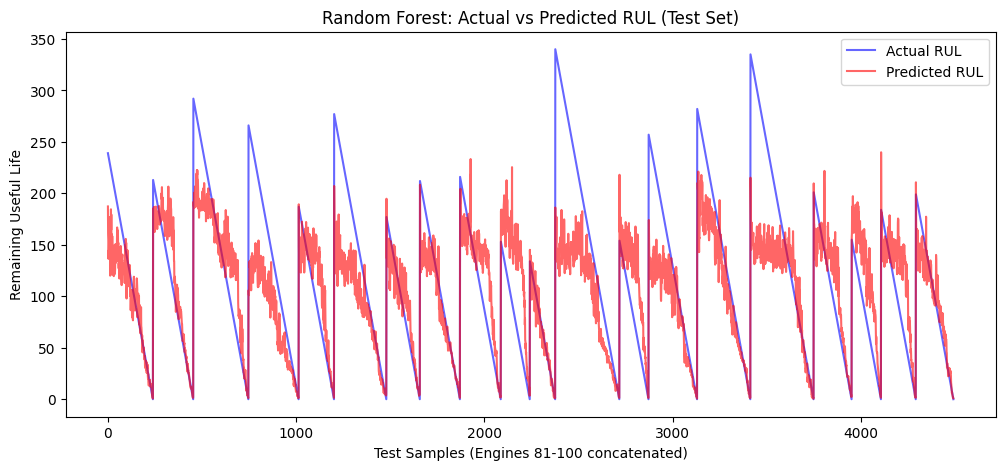

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual RUL', color='blue', alpha=0.6)
plt.plot(y_pred, label='Predicted RUL', color='red', alpha=0.6)
plt.title('Random Forest: Actual vs Predicted RUL (Test Set)')
plt.xlabel('Test Samples (Engines 81-100 concatenated)')
plt.ylabel('Remaining Useful Life')
plt.legend()
plt.show()

In [28]:


# 1. Apply Clipping (The Fix)
# We limit the RUL values. If it's > 125, it becomes 125.
clip_threshold = 125

# We must clip the training data so the model learns the "plateau"
y_train_clipped = y_train.clip(upper=clip_threshold)

# We also clip the test data for a fair comparison (we don't care about errors above 125)
y_test_clipped = y_test.clip(upper=clip_threshold)

print(f"RUL values clipped at {clip_threshold}. Re-training model...")

# 2. Re-Train the Random Forest
rf_model_v2 = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
rf_model_v2.fit(X_train, y_train_clipped)

# 3. Predict
y_pred_v2 = rf_model_v2.predict(X_test)

# 4. Check the Score
mse_v2 = mean_squared_error(y_test_clipped, y_pred_v2)
rmse_v2 = np.sqrt(mse_v2)

print("------------------------------------------------")
print(f"Previous RMSE: 51.00 (Approx)")
print(f"New RMSE:      {rmse_v2:.2f}")
print("------------------------------------------------")

RUL values clipped at 125. Re-training model...
------------------------------------------------
Previous RMSE: 51.00 (Approx)
New RMSE:      18.97
------------------------------------------------


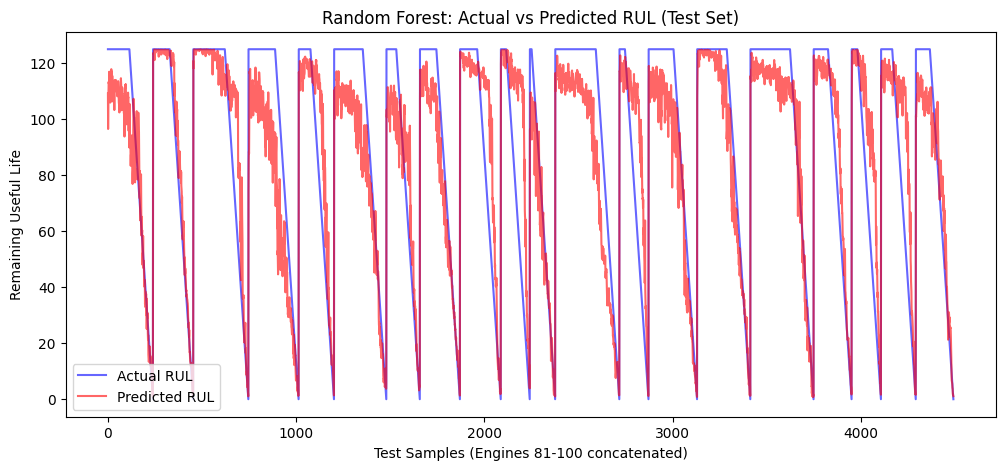

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(y_test_clipped.values, label='Actual RUL', color='blue', alpha=0.6)
plt.plot(y_pred_v2, label='Predicted RUL', color='red', alpha=0.6)
plt.title('Random Forest: Actual vs Predicted RUL (Test Set)')
plt.xlabel('Test Samples (Engines 81-100 concatenated)')
plt.ylabel('Remaining Useful Life')
plt.legend()
plt.show()

C:\Users\raman\AppData\Local\Temp\ipykernel_356\1723778329.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


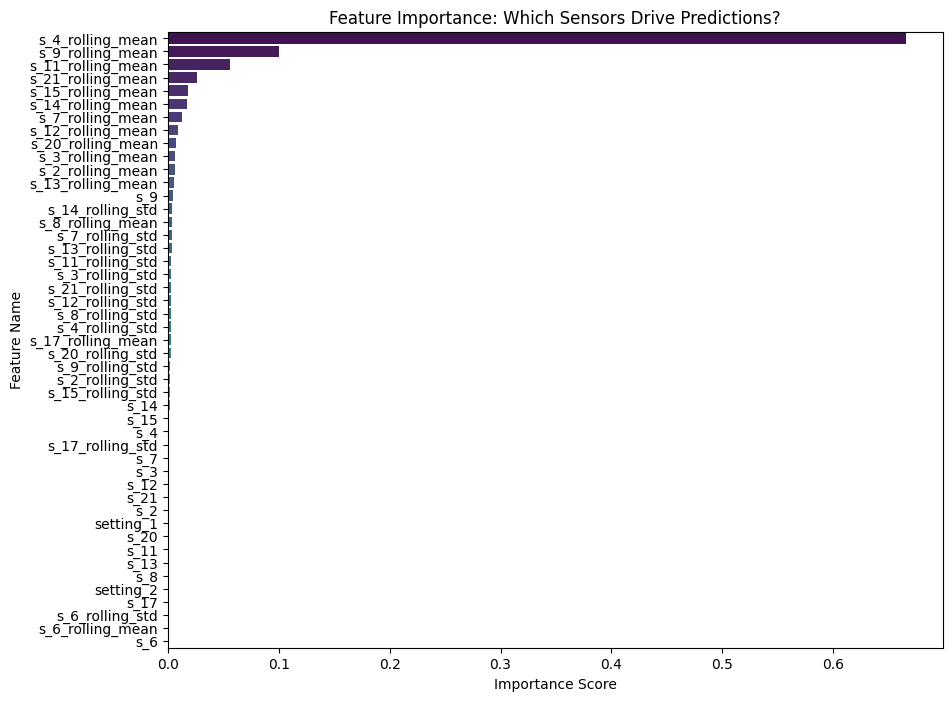

In [32]:
import seaborn as sns

# 1. Get the feature importances
importances = rf_model_v2.feature_importances_

# 2. Get the correct feature names directly from your training data
# This fixes the "ValueError: All arrays must be of the same length"
feature_names = X_train.columns 

# 3. Create the DataFrame
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 4. Sort by importance (Highest on top)
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 5. Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance: Which Sensors Drive Predictions?')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

In [33]:
feature_imp_df.shape

(47, 2)

In [34]:
import joblib

# 1. Define the filename
# It is good practice to include the RMSE in the name so you know this is the "good" one.
filename = 'cmapss_rf_model_rmse_19.joblib'

# 2. Save the model
# We are saving 'rf_model_v2' because that was the one with the clipping fix.
joblib.dump(rf_model_v2, filename)

print(f"Model successfully saved as {filename}")
print("You can now load this file in a different script to make predictions without training!")

Model successfully saved as cmapss_rf_model_rmse_19.joblib
You can now load this file in a different script to make predictions without training!


In [38]:
# 1. Load the FD002 Data
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f's_{i}' for i in range(1, 22)] 
col_names = index_names + setting_names + sensor_names

df_test_02 = pd.read_csv('../CMaps/test_FD002.txt', sep='\s+', header=None, names=col_names)
y_true_02 = pd.read_csv('../CMaps/RUL_FD002.txt', sep='\s+', header=None, names=['RUL'])

# 2. UPDATED Feature Engineering (Now includes Standard Deviation)
def add_rolling_features(df):
    sensor_cols = [c for c in df.columns if 's_' in c]
    
    # A. Calculate Rolling Mean
    rolled_mean = df.groupby('unit_nr')[sensor_cols].rolling(window=5, min_periods=1).mean()
    rolled_mean = rolled_mean.reset_index(level=0, drop=True)
    rolled_mean.columns = [f"{c}_rolling_mean" for c in rolled_mean.columns]

    # B. Calculate Rolling Standard Deviation (The missing piece!)
    rolled_std = df.groupby('unit_nr')[sensor_cols].rolling(window=5, min_periods=1).std()
    rolled_std = rolled_std.reset_index(level=0, drop=True)
    rolled_std.columns = [f"{c}_rolling_std" for c in rolled_std.columns]
    
    # Handle NaNs (std dev is NaN for the first cycle, fill with 0)
    rolled_std = rolled_std.fillna(0)

    # C. Combine Original + Mean + Std
    return pd.concat([df, rolled_mean, rolled_std], axis=1)

# Apply the fix
df_test_02 = add_rolling_features(df_test_02)

# 3. Prepare Data
last_rows_02 = df_test_02.groupby('unit_nr').last().reset_index()

# Select columns using X_train to ensure perfect match
X_test_02 = last_rows_02[X_train.columns]

# 4. Predict & Score
y_pred_02 = rf_model_v2.predict(X_test_02)
rmse_02 = np.sqrt(mean_squared_error(y_true_02, y_pred_02))

print(f"FD001 Model Performance (Baseline): RMSE ~ 19.00")
print(f"FD002 Model Performance (New Data): RMSE ~ {rmse_02:.2f}")

FD001 Model Performance (Baseline): RMSE ~ 19.00
FD002 Model Performance (New Data): RMSE ~ 54.29


In [39]:
# Create a sample CSV for the app
# We take the first 5 engines from the test set
sample_data = X_test.head(500).copy() # Take 500 rows

# Save it
sample_data.to_csv('Sample_Engine_Data.csv', index=False)

print("Created 'Sample_Engine_Data.csv'. You can upload this file to your Streamlit app!")

Created 'Sample_Engine_Data.csv'. You can upload this file to your Streamlit app!


In [41]:
%pip install streamlit


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/9.0 MB ? eta -:--:--
   --------------- ------------------------ 3.4/9.0 MB 20.2 MB/s eta 0:00:01
   ------------------------------------ --- 8.1/9.0 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------  8.9/9.0 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------- 9.0/9.0 MB 11.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   --------------------------------------- 795.4/795.4 kB 11.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   ------------------ --------------------- 3.1/6.9 MB 16.8 MB/s eta 0:00:01
   --------------------------- ------------ 4.7/6.9 MB 11.9 MB/s eta 0:00:01
   --------------------------------- ------ 5.8/6.9 MB 9.5 MB/s eta 0:00:01
   ------------------------------------- -- 6.6/6.9 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------  6.8/6.9 MB 7.5 MB/s eta 0:00:01
   -----------------